# KAN-CDSCO2004U  Machine Learning and Deep Learning

## Lab 9: Machine Learning and Deep Learning — ✅ Solution
**Estimated time: 1 hour**

### Learning Objectives
By the end of this exercise, you will be able to:
- Run the **Perceptron** algorithm on the Iris dataset
- Apply an **MLP Classifier** Neural Network
- Clean, scale, and split datasets for classification

**How to work through this notebook:**
- 🏃 **RUN** cells = Just execute the code to see the output
- ✏️ **TODO** cells = Write your own code or answer questions
- 📖 **READ** cells = Explanations to help you understand the concepts

✏️ **TODO**

# Exercise-01 Use Perceptron on Irisdataset.
- Run Perceptron on Iris dataset (use petal length, petal width festures only)

In [3]:
# Common imports
import numpy as np
import pandas as pd
import os
import matplotlib
import matplotlib.pyplot as plt

from sklearn import metrics
from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron
from matplotlib.colors import ListedColormap
from sklearn.neural_network import MLPClassifier # neural network
from sklearn.preprocessing import MinMaxScaler

### 💡 Detailed Code Explanation
| Syntax/Method | Detailed Explanation/Purpose |
|---|---|
| `import [module]` | Imports a Python module/library so we can use its functions. |
| `from [module] import [func]` | Imports only a specific function or class from a library, saving memory and keeping the code clean. |
| `load_iris()` | Loads the Iris flower dataset, a classic dataset in machine learning. It contains data on the sepal and petal dimensions of 3 iris species. |
| `iris.data` | Accesses the features (measurements) of the dataset. |
| `iris.target` | Accesses the target labels (species classifications 0, 1, or 2). |
| `[:, (2, 3)]` | NumPy array slicing syntax. The `:` slice means 'take all rows'. The `(2, 3)` means 'take only columns at index 2 (petal length) and index 3 (petal width)'. |
| `.astype(int)` | Converts the resulting boolean array (True/False) into integers (1/0). |


In [4]:
# Load the dataset
iris = load_iris()
X = iris.data[:, (2, 3)]  # petal length, petal width
y = (iris.target == 0).astype(int)

### 💡 Detailed Code Explanation
| Syntax/Method | Detailed Explanation/Purpose |
|---|---|
| `load_iris()` | Loads the Iris flower dataset, a classic dataset in machine learning. It contains data on the sepal and petal dimensions of 3 iris species. |
| `iris.data` | Accesses the features (measurements) of the dataset. |
| `iris.target` | Accesses the target labels (species classifications 0, 1, or 2). |
| `[:, (2, 3)]` | NumPy array slicing syntax. The `:` slice means 'take all rows'. The `(2, 3)` means 'take only columns at index 2 (petal length) and index 3 (petal width)'. |
| `.astype(int)` | Converts the resulting boolean array (True/False) into integers (1/0). |


In [5]:
#[TODO] Call the model and set max_iter and tol explicitly to avoid warnings about the fact that their default value
per_clf = Perceptron(max_iter=100, random_state=42)
per_clf.fit(X, y)

y_pred = per_clf.predict([[2, 0.5]])


# Additional transformations needed.
a = -per_clf.coef_[0][0] / per_clf.coef_[0][1]
b = -per_clf.intercept_ / per_clf.coef_[0][1]

axes = [0, 5, 0, 2]

x0, x1 = np.meshgrid(
        np.linspace(axes[0], axes[1], 500).reshape(-1, 1),
        np.linspace(axes[2], axes[3], 200).reshape(-1, 1),
    )
X_new = np.c_[x0.ravel(), x1.ravel()]
y_predict = per_clf.predict(X_new)
zz = y_predict.reshape(x0.shape)

#[Idea]: Go back to the slides and try to fully understand the perceptron. Then, the steps are easier to follow

### 💡 Detailed Code Explanation
| Syntax/Method | Detailed Explanation/Purpose |
|---|---|
| `Perceptron(...)` | Initializes the Perceptron strictly linear classifier algorithm. |
| `max_iter=100` | Limits the algorithm to a maximum of 100 passes over the training data, preventing infinite loops if the data is not perfectly linearly separable. |
| `.fit(X, y)` | Triggers the actual training process. The model learns the weights to best separate the classes based on inputs `X` and labels `y`. |
| `.predict(...)` | Uses the trained model to predict the class of brand new, unseen data points. |
| `np.meshgrid` | Creates a rectangular grid out of two given 1D arrays, useful for evaluating functions or plotting over a 2D area (like drawing decision boundaries). |
| `.ravel()` | Flattens a multi-dimensional array into a single 1D array. |
| `np.c_[...]` | A NumPy translator that stacks 1D arrays as columns to create a 2D array matrix. |


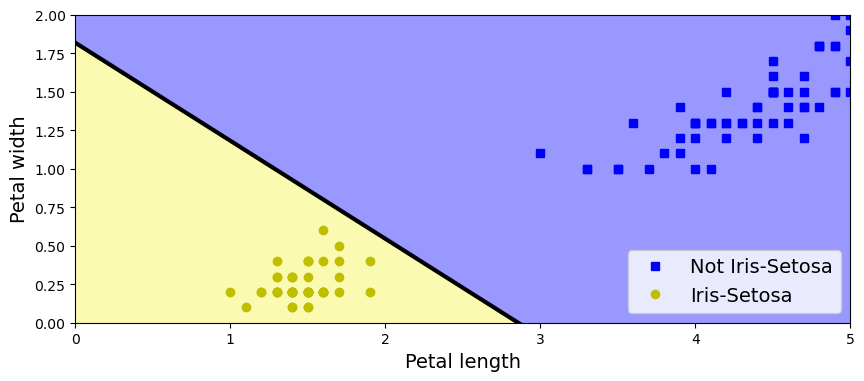

In [6]:
# Plot the result
plt.figure(figsize=(10, 4))
plt.plot(X[y==0, 0], X[y==0, 1], "bs", label="Not Iris-Setosa")
plt.plot(X[y==1, 0], X[y==1, 1], "yo", label="Iris-Setosa")

plt.plot([axes[0], axes[1]], [a * axes[0] + b, a * axes[1] + b], "k-", linewidth=3)

custom_cmap = ListedColormap(['#9898ff', '#fafab0'])


# To plot pretty figures
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12


plt.contourf(x0, x1, zz, cmap=custom_cmap)
plt.xlabel("Petal length", fontsize=14)
plt.ylabel("Petal width", fontsize=14)
plt.legend(loc="lower right", fontsize=14)
plt.axis(axes)
plt.show()

#[Idea]: Store the plotting functions in a cheat-sheet notebook that you can access whenever needed
#[Idea]: If unsure try to present the diagram in your own words to fully understand what you are seeing.

### 💡 Detailed Code Explanation
| Syntax/Method | Detailed Explanation/Purpose |
|---|---|
| `plt.plot(...)` | Plots points or lines on the graph (e.g., drawing class boundaries or scattering the iris data). |
| `plt.contourf(...)` | Draws filled contours. Here it visually shades the regions on the plot corresponding to where the Perceptron predicts class 0 versus class 1. |
| `ListedColormap` | Creates a concise, custom color mapping for the plot shading (like using light blue `#9898ff` for one class and pale yellow `#fafab0` for the other). |
| `plt.xlabel` / `ylabel` | Labels the X and Y axes for readability. |
| `plt.legend(...)` | Places a legend box on the plot to identify what each marker represents. `loc="lower right"` anchors it out of the way. |
| `plt.show()` | Renders the final combined plot to the output cell. |


✏️ **TODO**

## Now apply MLP on the above data
- Now, we want to use all 4 features as X and three classes as y. 
- Use a MLP Neural Network with 50 hidden layers

In [8]:
# [TODO] This time please use all 4 variables as X and
# all three classes as Y 
y = iris.target
X = iris.data

### 💡 Detailed Code Explanation
| Syntax/Method | Detailed Explanation/Purpose |
|---|---|
| `y = iris.target` | Grabs the true labels for all irises (0, 1, or 2). |
| `X = iris.data` | Grabs the all 4 measurement features for all irises. We use all columns this time instead of just the last two. |


In [9]:
#[TODO] Rename the  columns according to the following list 'SepalLengthCm','SepalWidthCm','PetalLengthCm','PetalWidthCm'.
#[TODO] Please add the labels to the dataframe
column_names = ['SepalLengthCm','SepalWidthCm','PetalLengthCm','PetalWidthCm']
iris_dataset = pd.DataFrame(X, columns= column_names)
iris_dataset["y"] = y

### 💡 Detailed Code Explanation
| Syntax/Method | Detailed Explanation/Purpose |
|---|---|
| `pd.DataFrame(...)` | Constructor from the `pandas` library. Converts purely numerical 2D arrays into a tabular DataFrame, giving columns distinct, readable names. |
| `columns=column_names` | Applies a predefined list of string names directly to the columns. |
| `iris_dataset["y"] = y` | Adds a brand new column named 'y' to the right edge of the DataFrame, populating it with the target labels. |


In [10]:
#[TODO] Get summary statisticy for all features
iris_dataset.drop(columns=["y"]).describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


### 💡 Detailed Code Explanation
| Syntax/Method | Detailed Explanation/Purpose |
|---|---|
| `.drop(columns=["y"])` | Temporarily removes the 'y' column so it isn't included in the feature statistics, as taking the "mean" of a class label (0, 1, 2) is mathematically meaningless. |
| `.describe()` | Automatically calculates count, mean, standard deviation, min, max, and percentiles for every numeric column. Highlighting the scale of data distributions. |


In [11]:
#[TODO] Please randomly shuffle the dataset, because the labels are in order. This would be problematic when training the NN later
iris_dataset= iris_dataset.sample(frac=1).reset_index(drop=True)
iris_dataset

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,y
0,5.0,3.6,1.4,0.2,0
1,5.1,3.8,1.9,0.4,0
2,5.2,2.7,3.9,1.4,1
3,6.3,2.9,5.6,1.8,2
4,6.7,3.1,4.7,1.5,1
...,...,...,...,...,...
145,6.3,3.3,4.7,1.6,1
146,6.4,3.2,5.3,2.3,2
147,6.5,3.0,5.8,2.2,2
148,6.2,3.4,5.4,2.3,2


### 💡 Detailed Code Explanation
| Syntax/Method | Detailed Explanation/Purpose |
|---|---|
| `.sample(frac=1)` | A pandas function that returns a random sample of items from an axis. Passing `frac=1` means "sample 100% of the rows", which effectively acts as a dynamic shuffle of the entire dataset. This is critical because the Iris dataset comes strictly sorted by class (all 0s, then all 1s, then all 2s). |
| `.reset_index(drop=True)` | After shuffling, the old sequence indices (row numbers) are scrambled. This resets them to 0...N without keeping the old jumbled index as a new column. |


In [12]:
#[TODO] Rescale the data with the min-max Scaler
scaler = MinMaxScaler()
X = scaler.fit_transform(iris_dataset.drop(columns=["y"]))

### 💡 Detailed Code Explanation
| Syntax/Method | Detailed Explanation/Purpose |
|---|---|
| `MinMaxScaler()` | An algorithm from sklearn that rescales all numerical features to exactly bound between 0 and 1. Neural networks heavily rely on input variables having similar scales to train effectively and stably. |
| `.fit_transform(...)` | Calculates the min and max for each column (the `fit` step), and simultaneously applies the scaling math to the data (the `transform` step) returning the scaled array matrix. |


In [13]:
#[TODO] Please split the data into train and test. 
# Please use the first 110 observations of the reshuffled data as train, the rest as split
X_train = X[0:110]
X_test = X[110:]
y_train = iris_dataset["y"][0:110]
y_test = iris_dataset["y"][110:]

### 💡 Detailed Code Explanation
| Syntax/Method | Detailed Explanation/Purpose |
|---|---|
| `X[0:110]` | Python syntax for array slicing: grabs the first 110 rows of the feature data to act as the Training set. |
| `X[110:]` | Grabs every row from index 110 up to the end to act as the explicit Test set. We keep these separated so we can evaluate our model on data it has never seen before. |


In [14]:
#[TO-DO] Please use MLPClassifier to classify the observations. 
# Please use relu as the activation function
# Set alpha to 0.0001 and use a hidden layer size of 3x3. 
# Please explain, why the size will be 3 x 3.
clf = MLPClassifier(solver="lbfgs",activation="relu", alpha=1e-4, hidden_layer_sizes=(3, 3), random_state=11)

### 💡 Detailed Code Explanation
| Syntax/Method | Detailed Explanation/Purpose |
|---|---|
| `MLPClassifier(...)` | Multi-Layer Perceptron Classifier. This is the core Neural Network algorithm in scikit-learn. |
| `solver="lbfgs"` | The weight optimization algorithm. "lbfgs" is an optimizer in the family of quasi-Newton methods that often converges faster and performs better on very small datasets (like the 150-row Iris dataset) than the standard Adam or SGD solvers. |
| `activation="relu"` | Defines the Rectified Linear Unit activation function `f(x) = max(0, x)`. It breaks linearity, allowing the network to learn complex patterns without succumbing to the vanishing gradient problem. |
| `alpha=1e-4` | L2 penalty (regularization term) parameter. Prevents the neural network from maliciously overfitting on the training data. |
| `hidden_layer_sizes=(3, 3)` | Configures the topology of the hidden layers. `(3, 3)` means two consecutive hidden layers, each populated with precisely 3 artificial neurons. |
| `random_state=11` | Ensures reproducible initialization of weights so everyone gets the exact same results. |


In [15]:
#[To-Do] Please fit the classifier on the training data
clf.fit(X_train, y_train)

/home/somnath/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:545: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


MLPClassifier(hidden_layer_sizes=(3, 3), random_state=11, solver='lbfgs')

### 💡 Detailed Code Explanation
| Syntax/Method | Detailed Explanation/Purpose |
|---|---|
| *(General Code)* | Implements the logic configured in the previous step. |


In [16]:
#[TO-DO] Please predict the labels of the test set and print the labels
y_pred = clf.predict(X_test)
print(y_pred)

[2 2 2 1 0 0 1 0 0 2 0 0 2 2 0 0 2 1 0 2 0 0 1 0 0 2 2 0 1 1 1 0 0 0 2 1 2
 2 2 1]


### 💡 Detailed Code Explanation
| Syntax/Method | Detailed Explanation/Purpose |
|---|---|
| *(General Code)* | Implements the logic configured in the previous step. |


In [17]:
#[To-DO] Calculate the accuracy
print('The accuracy of the Multi-layer Perceptron is:', round(metrics.accuracy_score(y_pred,y_test),2))
#[Idea]: Reflect upon the accuracy

The accuracy of the Multi-layer Perceptron is: 0.97


### 💡 Detailed Code Explanation
| Syntax/Method | Detailed Explanation/Purpose |
|---|---|
| *(General Code)* | Implements the logic configured in the previous step. |


🏃 **RUN**

# Exercise-02. Visualization of MLP weights on MNIST dataset
- Use MLP for the the MNIST dataset to visualize the MLP weights. use MLPClassifier from scikit library to do that.
- Call SGD solver

In [19]:
#import the packages
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.neural_network import MLPClassifier

### 💡 Detailed Code Explanation
| Syntax/Method | Detailed Explanation/Purpose |
|---|---|
| `import [module]` | Imports a Python module/library so we can use its functions. |
| `from [module] import [func]` | Imports only a specific function or class from a library, saving memory and keeping the code clean. |


In [20]:
# Load data from https://www.openml.org/d/554; 
# https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_openml.html
X, y = fetch_openml('mnist_784', version=1, return_X_y=True) #returns (data, target) instead of a Bunch object
X = X / 255.

#[Idea]: Read through the documentation to understand what the data is about. Then, the operations are easier to understand

### 💡 Detailed Code Explanation
| Syntax/Method | Detailed Explanation/Purpose |
|---|---|
| *(General Code)* | Implements the logic configured in the previous step. |


In [21]:
# [TODO] Rescale the data, use the traditional train/test split 
# First 600000 oberservations should be training, the rest test set
# train, test split
X_train, X_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]

### 💡 Detailed Code Explanation
| Syntax/Method | Detailed Explanation/Purpose |
|---|---|
| *(General Code)* | Implements the logic configured in the previous step. |


In [22]:
# [TODO] call the MLP classifier and fit the model, set 100 as iteration limit
# [Hints]: 50 as hidden layer sizes, alpha to 1e-4 and use SGD as optimiser
mlp = MLPClassifier(hidden_layer_sizes=(50,), max_iter=100, alpha=1e-4,
                    solver='sgd', verbose=10, random_state=1,
                    learning_rate_init=.1)

mlp.fit(X_train, y_train)
print("Training set score: %f" % mlp.score(X_train, y_train))
print("Test set score: %f" % mlp.score(X_test, y_test))

Iteration 1, loss = 0.32009978
Iteration 2, loss = 0.15347534
Iteration 3, loss = 0.11544755
Iteration 4, loss = 0.09279764
Iteration 5, loss = 0.07889367
Iteration 6, loss = 0.07170497
Iteration 7, loss = 0.06282111
Iteration 8, loss = 0.05530788
Iteration 9, loss = 0.04960484
Iteration 10, loss = 0.04645355
Iteration 11, loss = 0.04082169
Iteration 12, loss = 0.03828222
Iteration 13, loss = 0.03557957
Iteration 14, loss = 0.03054891
Iteration 15, loss = 0.02924761
Iteration 16, loss = 0.02610471
Iteration 17, loss = 0.02363894
Iteration 18, loss = 0.02208186
Iteration 19, loss = 0.01932900
Iteration 20, loss = 0.01830387
Iteration 21, loss = 0.01639227
Iteration 22, loss = 0.01392950
Iteration 23, loss = 0.01270193
Iteration 24, loss = 0.01234102
Iteration 25, loss = 0.01081313
Iteration 26, loss = 0.01028644
Iteration 27, loss = 0.00896707
Iteration 28, loss = 0.00744908
Iteration 29, loss = 0.00707946
Iteration 30, loss = 0.00573869
Iteration 31, loss = 0.00499554
Iteration 32, los

### 💡 Detailed Code Explanation
| Syntax/Method | Detailed Explanation/Purpose |
|---|---|
| `MLPClassifier(...)` | Multi-Layer Perceptron Classifier. This is the core Neural Network algorithm in scikit-learn. |
| `solver="lbfgs"` | The weight optimization algorithm. "lbfgs" is an optimizer in the family of quasi-Newton methods that often converges faster and performs better on very small datasets (like the 150-row Iris dataset) than the standard Adam or SGD solvers. |
| `activation="relu"` | Defines the Rectified Linear Unit activation function `f(x) = max(0, x)`. It breaks linearity, allowing the network to learn complex patterns without succumbing to the vanishing gradient problem. |
| `alpha=1e-4` | L2 penalty (regularization term) parameter. Prevents the neural network from maliciously overfitting on the training data. |
| `hidden_layer_sizes=(3, 3)` | Configures the topology of the hidden layers. `(3, 3)` means two consecutive hidden layers, each populated with precisely 3 artificial neurons. |
| `random_state=11` | Ensures reproducible initialization of weights so everyone gets the exact same results. |


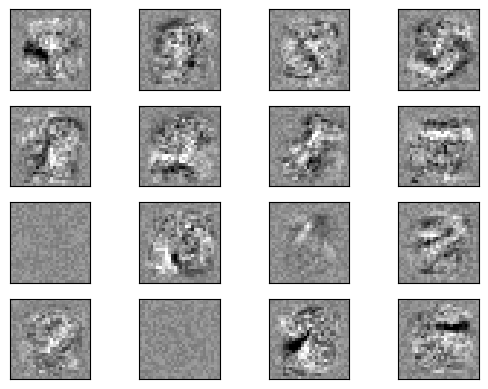

In [23]:
# [TODO] plot the result
# [TODO] use global min / max to ensure all weights are shown on the same scale and finally plot it

fig, axes = plt.subplots(4, 4)

vmin, vmax = mlp.coefs_[0].min(), mlp.coefs_[0].max()
for coef, ax in zip(mlp.coefs_[0].T, axes.ravel()):
    ax.matshow(coef.reshape(28, 28), cmap=plt.cm.gray, vmin=.5 * vmin,
               vmax=.5 * vmax)
    ax.set_xticks(())
    ax.set_yticks(())

plt.show()

#[Idea]: Store the plotting functions in a cheat-sheet notebook that you can access whenever needed

### 💡 Detailed Code Explanation
| Syntax/Method | Detailed Explanation/Purpose |
|---|---|
| *(General Code)* | Implements the logic configured in the previous step. |


### 📚 Methods and Functions Used Summary

| Library / Module | Function / Method | Purpose |
|-----------------|-------------------|---------|
| `sklearn.datasets` | `load_iris()` | Loads the classic Iris flower morphological dataset. |
| `sklearn.linear_model` | `Perceptron` | Model class for the simplest, linear binary-classifier neural network. |
| `sklearn.neural_network` | `MLPClassifier` | The Multi-Layer Perceptron neural network model. |
| `sklearn.preprocessing` | `MinMaxScaler` | Standardizes features by scaling each to tightly fit a given range (0 to 1). |
| `pandas` | `DataFrame`, `.describe()`, `.sample()`, `.reset_index()` | Essential tools for building, analyzing, shuffling, and indexing tabular data structures. |
| `matplotlib.pyplot` | `plot()`, `contourf()`, `xlabel()`, `show()` | Critical methods for visually plotting point scatters, lines, decision boundaries, and rendering them beautifully to the screen. |
| `numpy` | `meshgrid()`, `ravel()`, `c_[]` | Highly optimized arrays and grid mathematical operators for constructing the layout of plot decision borders. |